# Quickstart

The primary pipeline functions `run_plane` and `run_volume` take planar (3D, TYX), contiguious files as inputs.

This is briefly shown in [data-extraction](./data_extraction.ipynb).

We will use the output of `mbo.imwrite` in that notebook as input here.

In [2]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import mbo_utilities as mbo
import lbm_suite2p_python as lsp

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,553.09
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 553.09


In [3]:
# !uv pip install torch --torch-backend=auto

In [4]:
import fastplotlib as fpl
from copy import deepcopy
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p

In [5]:
input_files = mbo.get_files("D://demo//mrois", 'tif')
input_files  # first 2 files

[WindowsPath('D:/demo/mrois/plane01_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane02_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane03_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane04_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane05_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane06_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane07_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane08_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane09_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane10_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane11_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane12_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane13_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane14_roi1.tif'),
 WindowsPath('D:/demo/mrois/plane01_roi2.tif'),
 WindowsPath('D:/demo/mrois/plane02_roi2.tif'),
 WindowsPath('D:/demo/mrois/plane03_roi2.tif'),
 WindowsPath('D:/demo/mrois/plane04_roi2.tif'),
 WindowsPath('D:/demo/mrois/plane05_roi2.tif'),
 WindowsPath('D:/demo/mrois/plane06_roi2.tif'),
 WindowsPath('D:/demo/mrois/plane07_roi2

## Run a single z-plane

Below are the defaults, with a single path to an [assembled](https://millerbrainobservatory.github.io/mbo_utilities/assembly.html#save-assembled-files) scanimage tiff.

By default, metadata is used to pre-fill 'dx', 'dy', 'fs', and some output-related parameters.

User-defined options will take precendence to the defaults.

In [6]:
new_ops = {
    "anatomical_only": 3,
    "two_step_registration": True,
}

save_path = r"D://demo//suite2p"  # will be created if it doesn't exist

In [9]:
output_ops = lsp.run_plane(
    input_path=input_files[0],  # run_plane takes a single input fileppath        
    save_path=save_path,
    ops=new_ops,         # default is None
    keep_raw=True,       # default is False
    keep_reg=True,       # default is True
    force_reg=False,     # default is False
    force_detect=False,  # default is False
)

ops['roidetect'] is True with no stat.npy file present, proceeding with segmentation/detection for plane 1.


Saving data_raw.bin:   0%|          | 0/9 [00:00<?, ?it/s]

NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 13.23 sec.
Registered 500/701 in 51.40s
Registered 701/701 in 70.67s
----------- Total 85.66 sec
----------- ROI DETECTION
Binning movie in chunks of length 14
Binned movie of size [50,540,218] created in 0.21 sec.


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.12.9 
torch version:  	2.8.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




model_type argument is not used in v4.0.1+. Ignoring this argument...


>>>> CELLPOSE finding masks in enhanced_mean_img
!NOTE! diameter set to 8.00 for cell detection with cellpose
Cellpose using GPU: True


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is depricated in v4.0.1+


>>>> 172 masks detected, median diameter = 10.55 
Detected 172 ROIs, 4.98 sec
After removing overlaps, 172 ROIs remain
----------- Total 8.48 sec.
----------- EXTRACTION
Masks created, 0.40 sec.
Extracted fluorescence from 172 ROIs in 701 frames, 8.57 sec.
----------- Total 8.97 sec.
----------- CLASSIFICATION
['compact', 'skew', 'npix_norm']
----------- SPIKE DECONVOLUTION
----------- Total 0.01 sec.
1500 frames needed for registration metrics, found 701. Skipping PC metrics.


## Preview outputs

In [47]:
from pprint import pprint
output_files = list(Path(save_path).rglob("*.*"))
pprint(output_files)

[WindowsPath('D:/demo/suite2p/data.bin'),
 WindowsPath('D:/demo/suite2p/data_raw.bin'),
 WindowsPath('D:/demo/suite2p/F.npy'),
 WindowsPath('D:/demo/suite2p/Fneu.npy'),
 WindowsPath('D:/demo/suite2p/iscell.npy'),
 WindowsPath('D:/demo/suite2p/max_projection_image.png'),
 WindowsPath('D:/demo/suite2p/mean_image.png'),
 WindowsPath('D:/demo/suite2p/mean_image_enhanced.png'),
 WindowsPath('D:/demo/suite2p/metadata.html'),
 WindowsPath('D:/demo/suite2p/ops.npy'),
 WindowsPath('D:/demo/suite2p/segmentation_accepted.png'),
 WindowsPath('D:/demo/suite2p/segmentation_rejected_area_filter.png'),
 WindowsPath('D:/demo/suite2p/shot_noise_distrubution_accepted.png'),
 WindowsPath('D:/demo/suite2p/shot_noise_distrubution_rejected.png'),
 WindowsPath('D:/demo/suite2p/spks.npy'),
 WindowsPath('D:/demo/suite2p/stat.npy'),
 WindowsPath('D:/demo/suite2p/traces_dff.png'),
 WindowsPath('D:/demo/suite2p/traces_raw.png')]



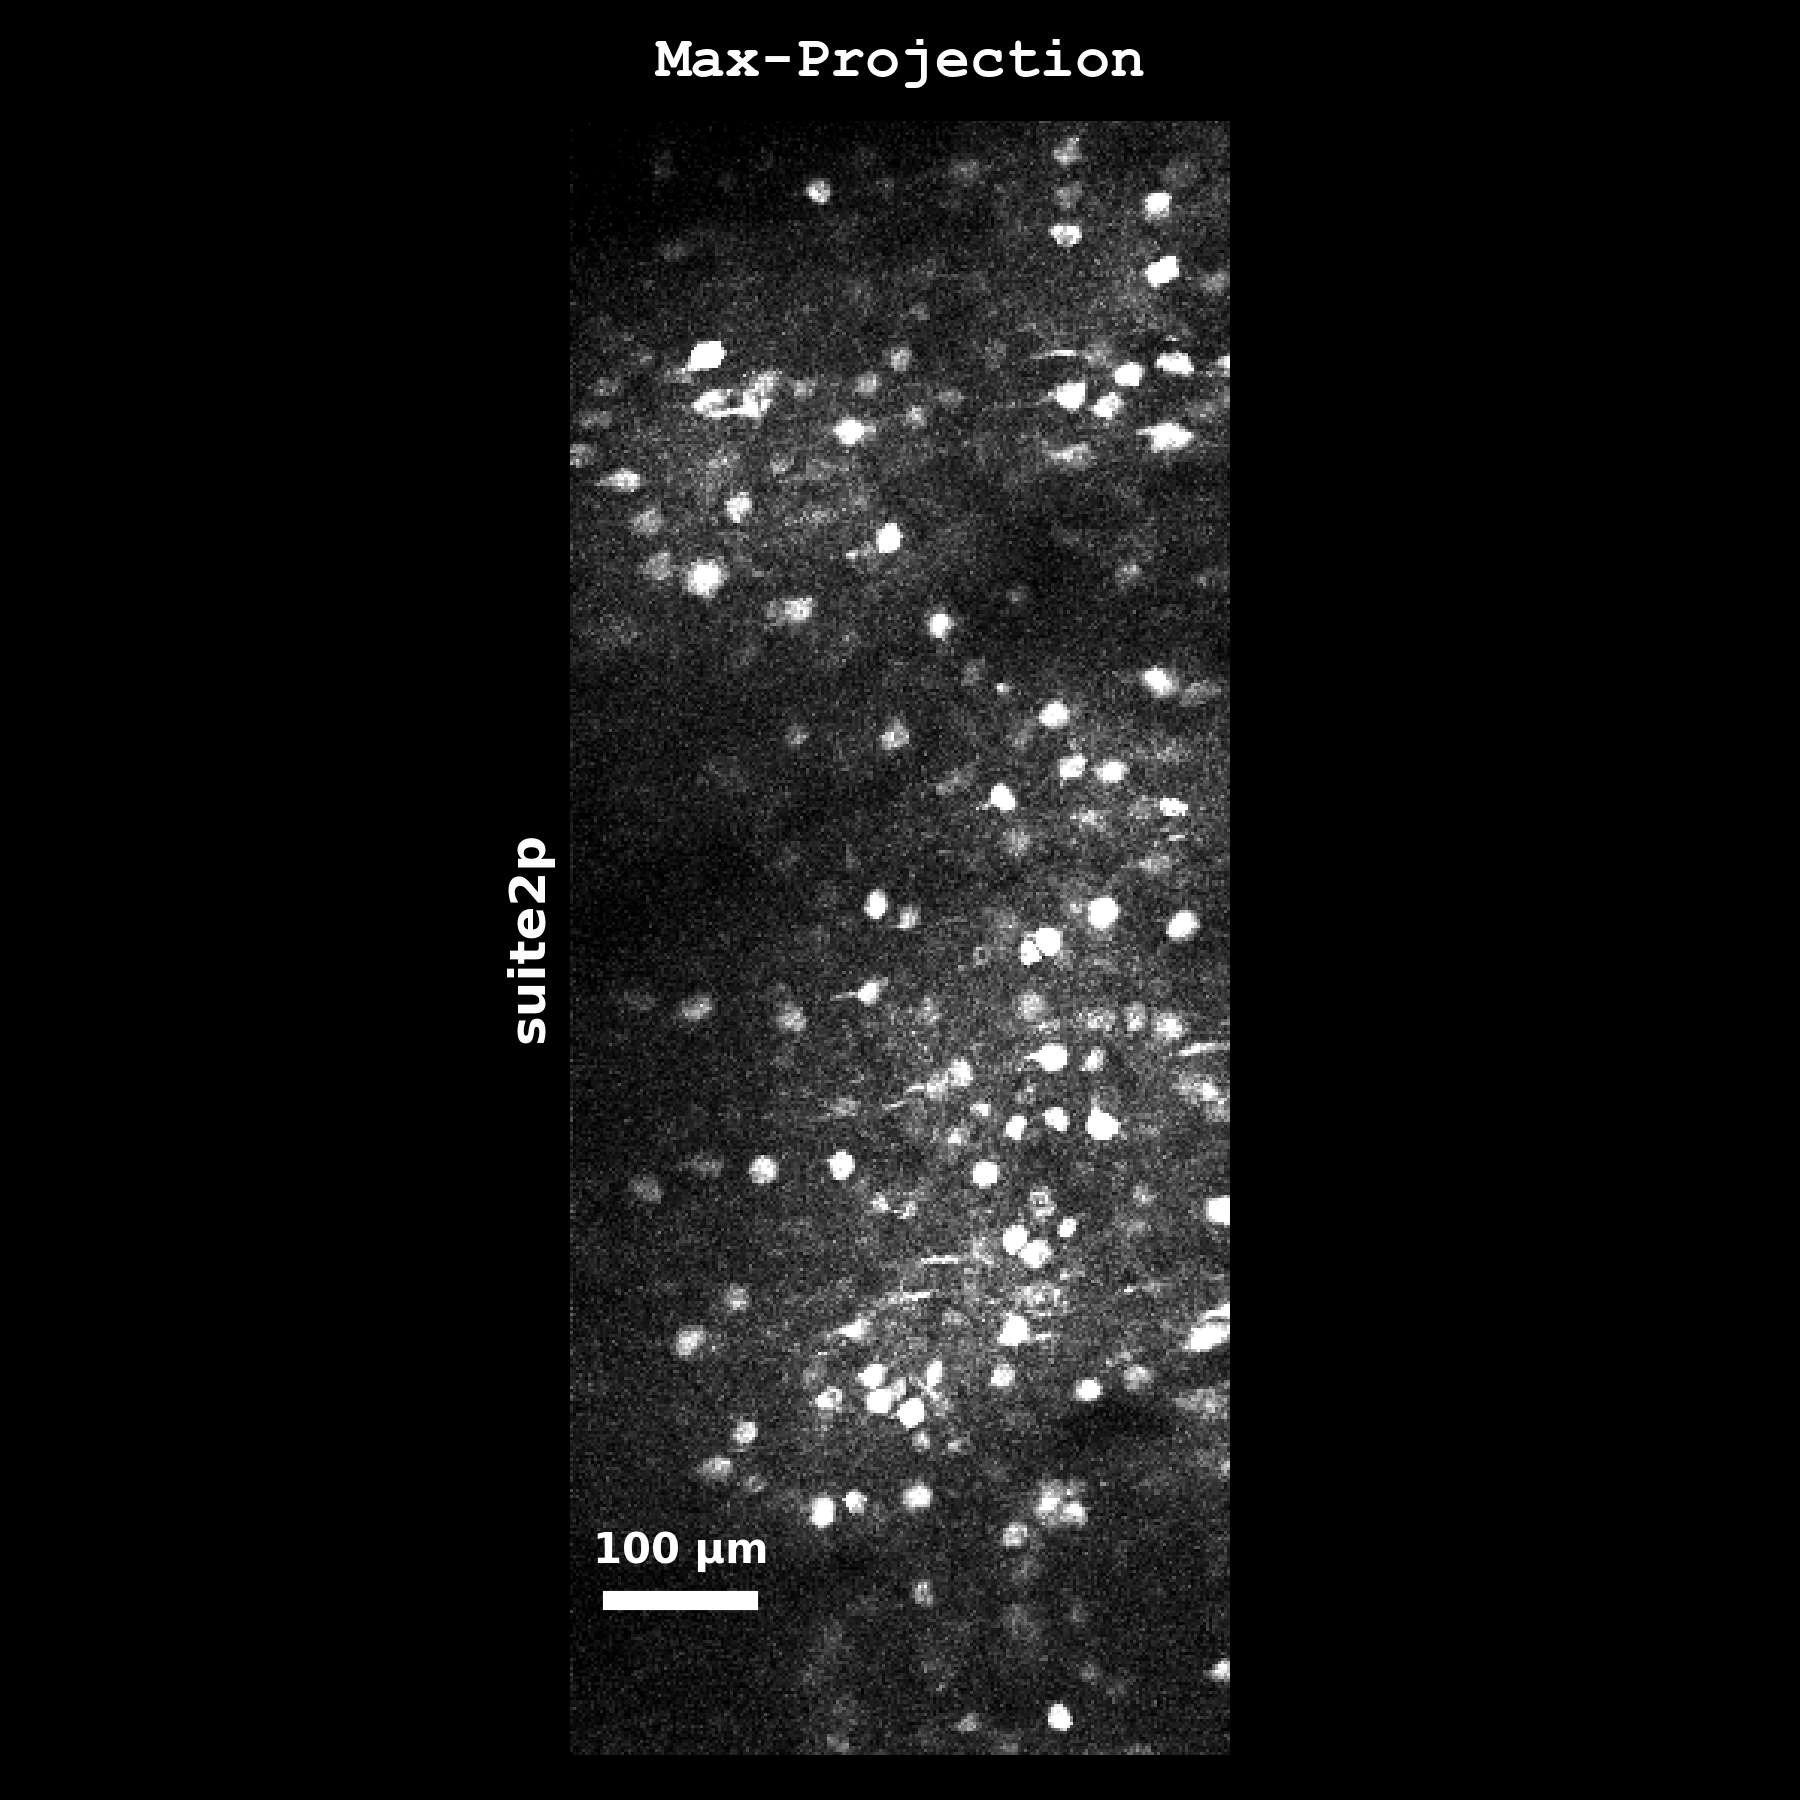
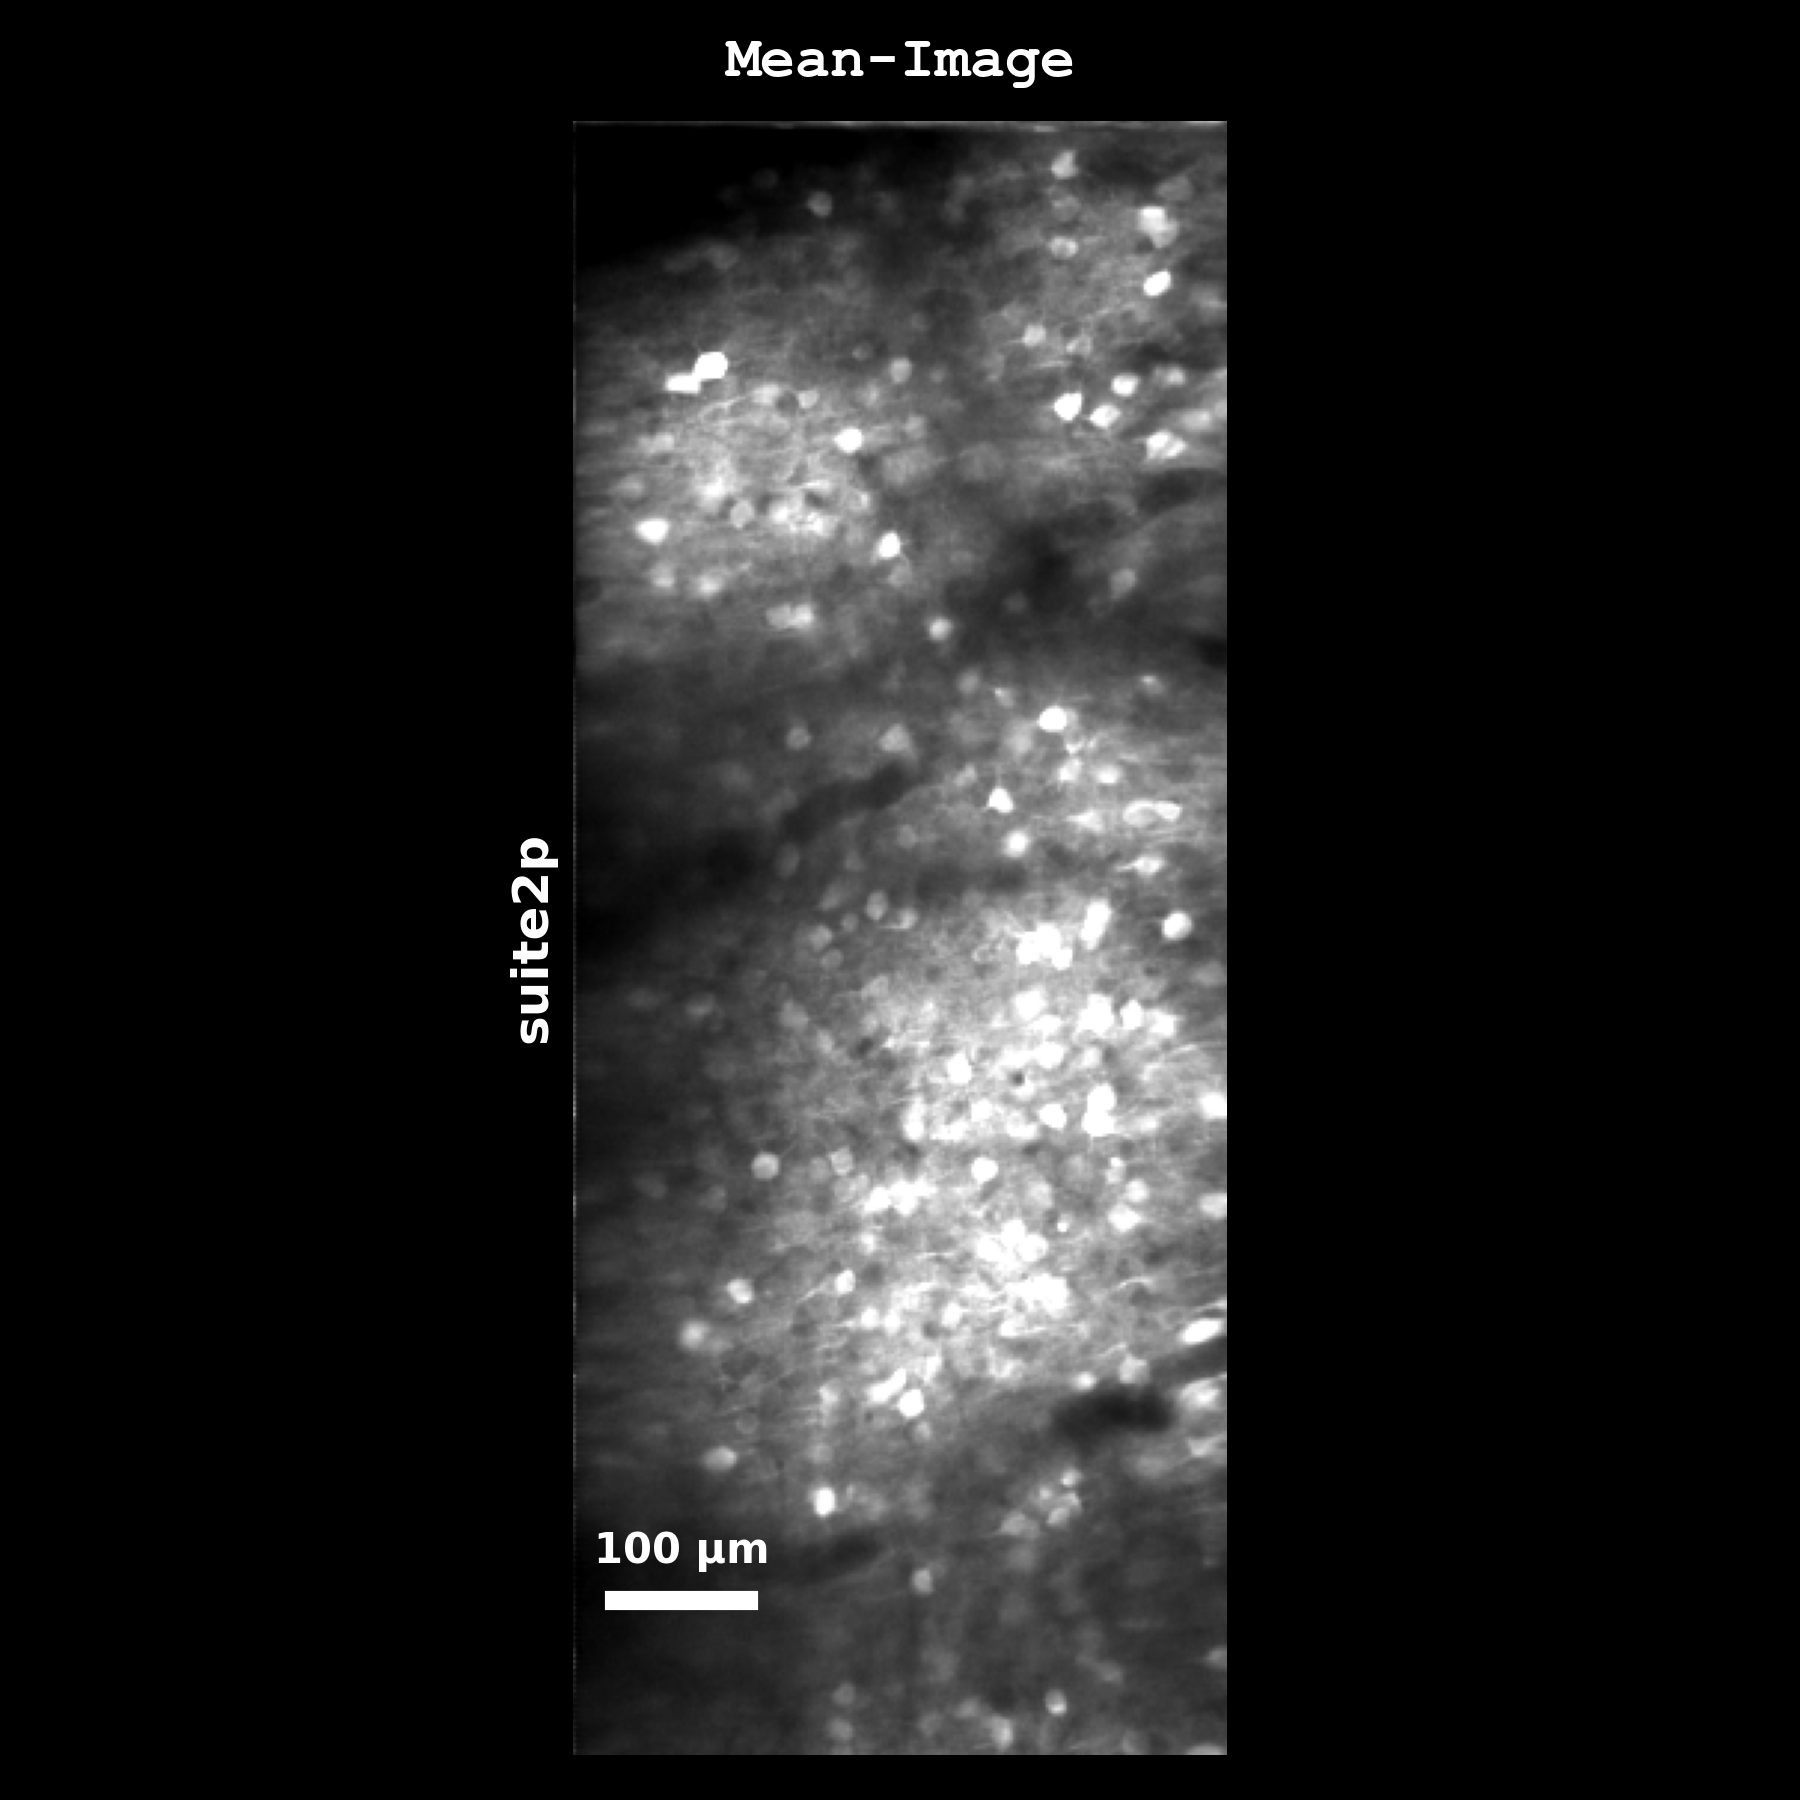
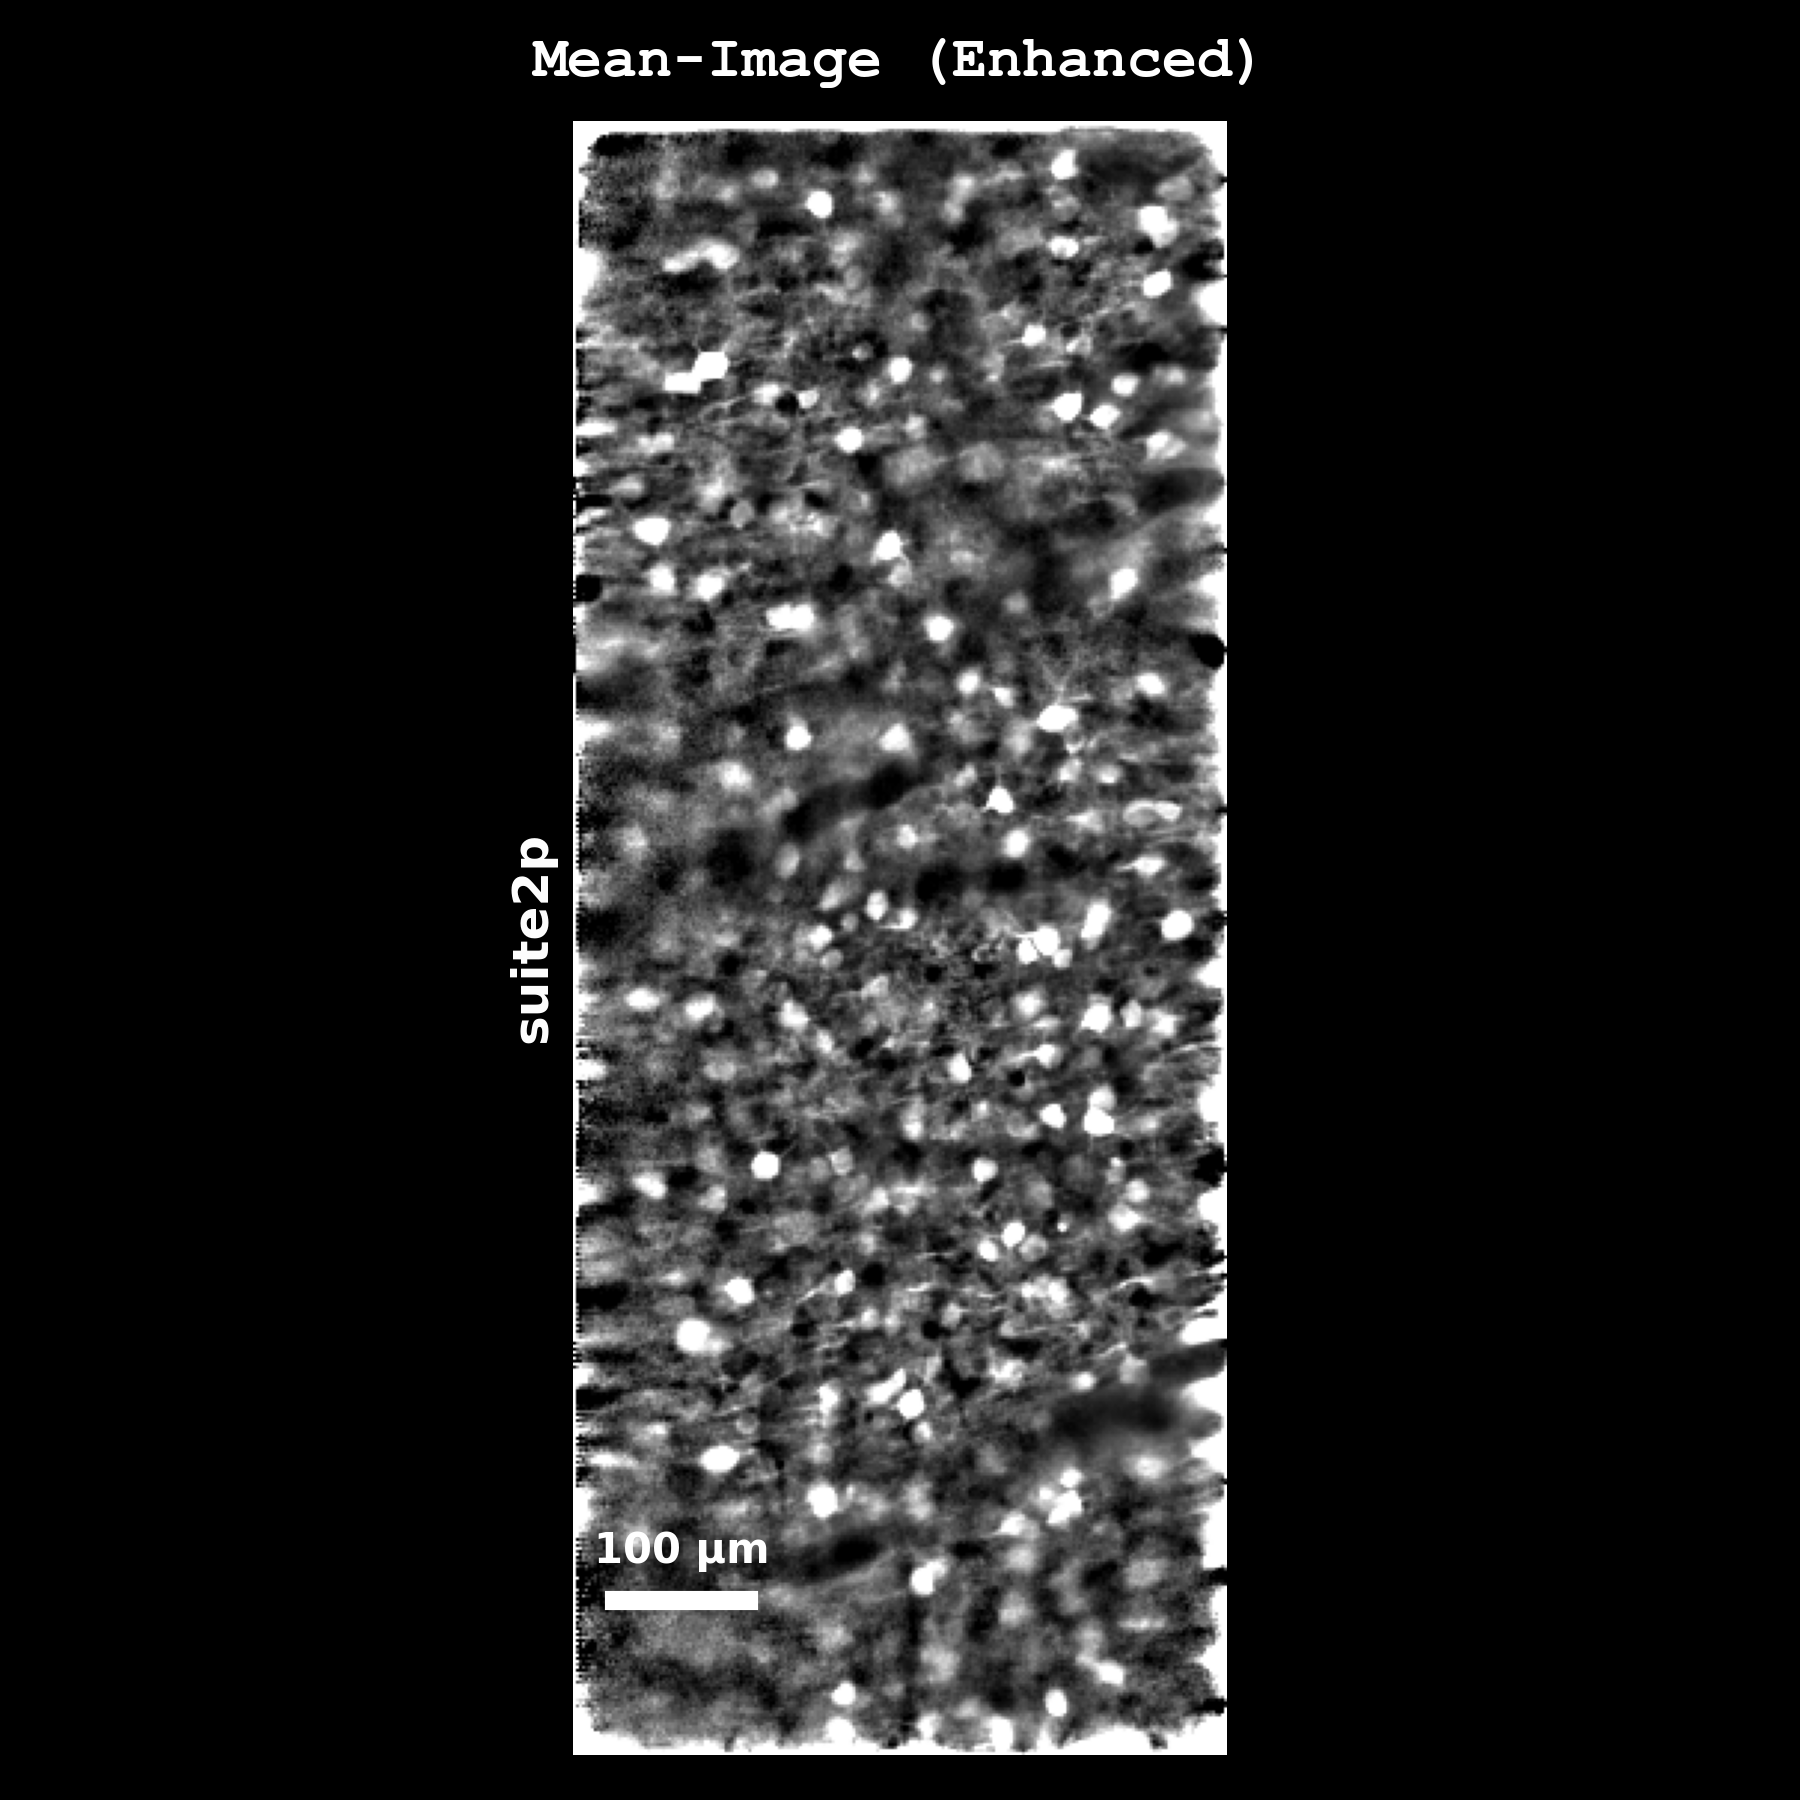
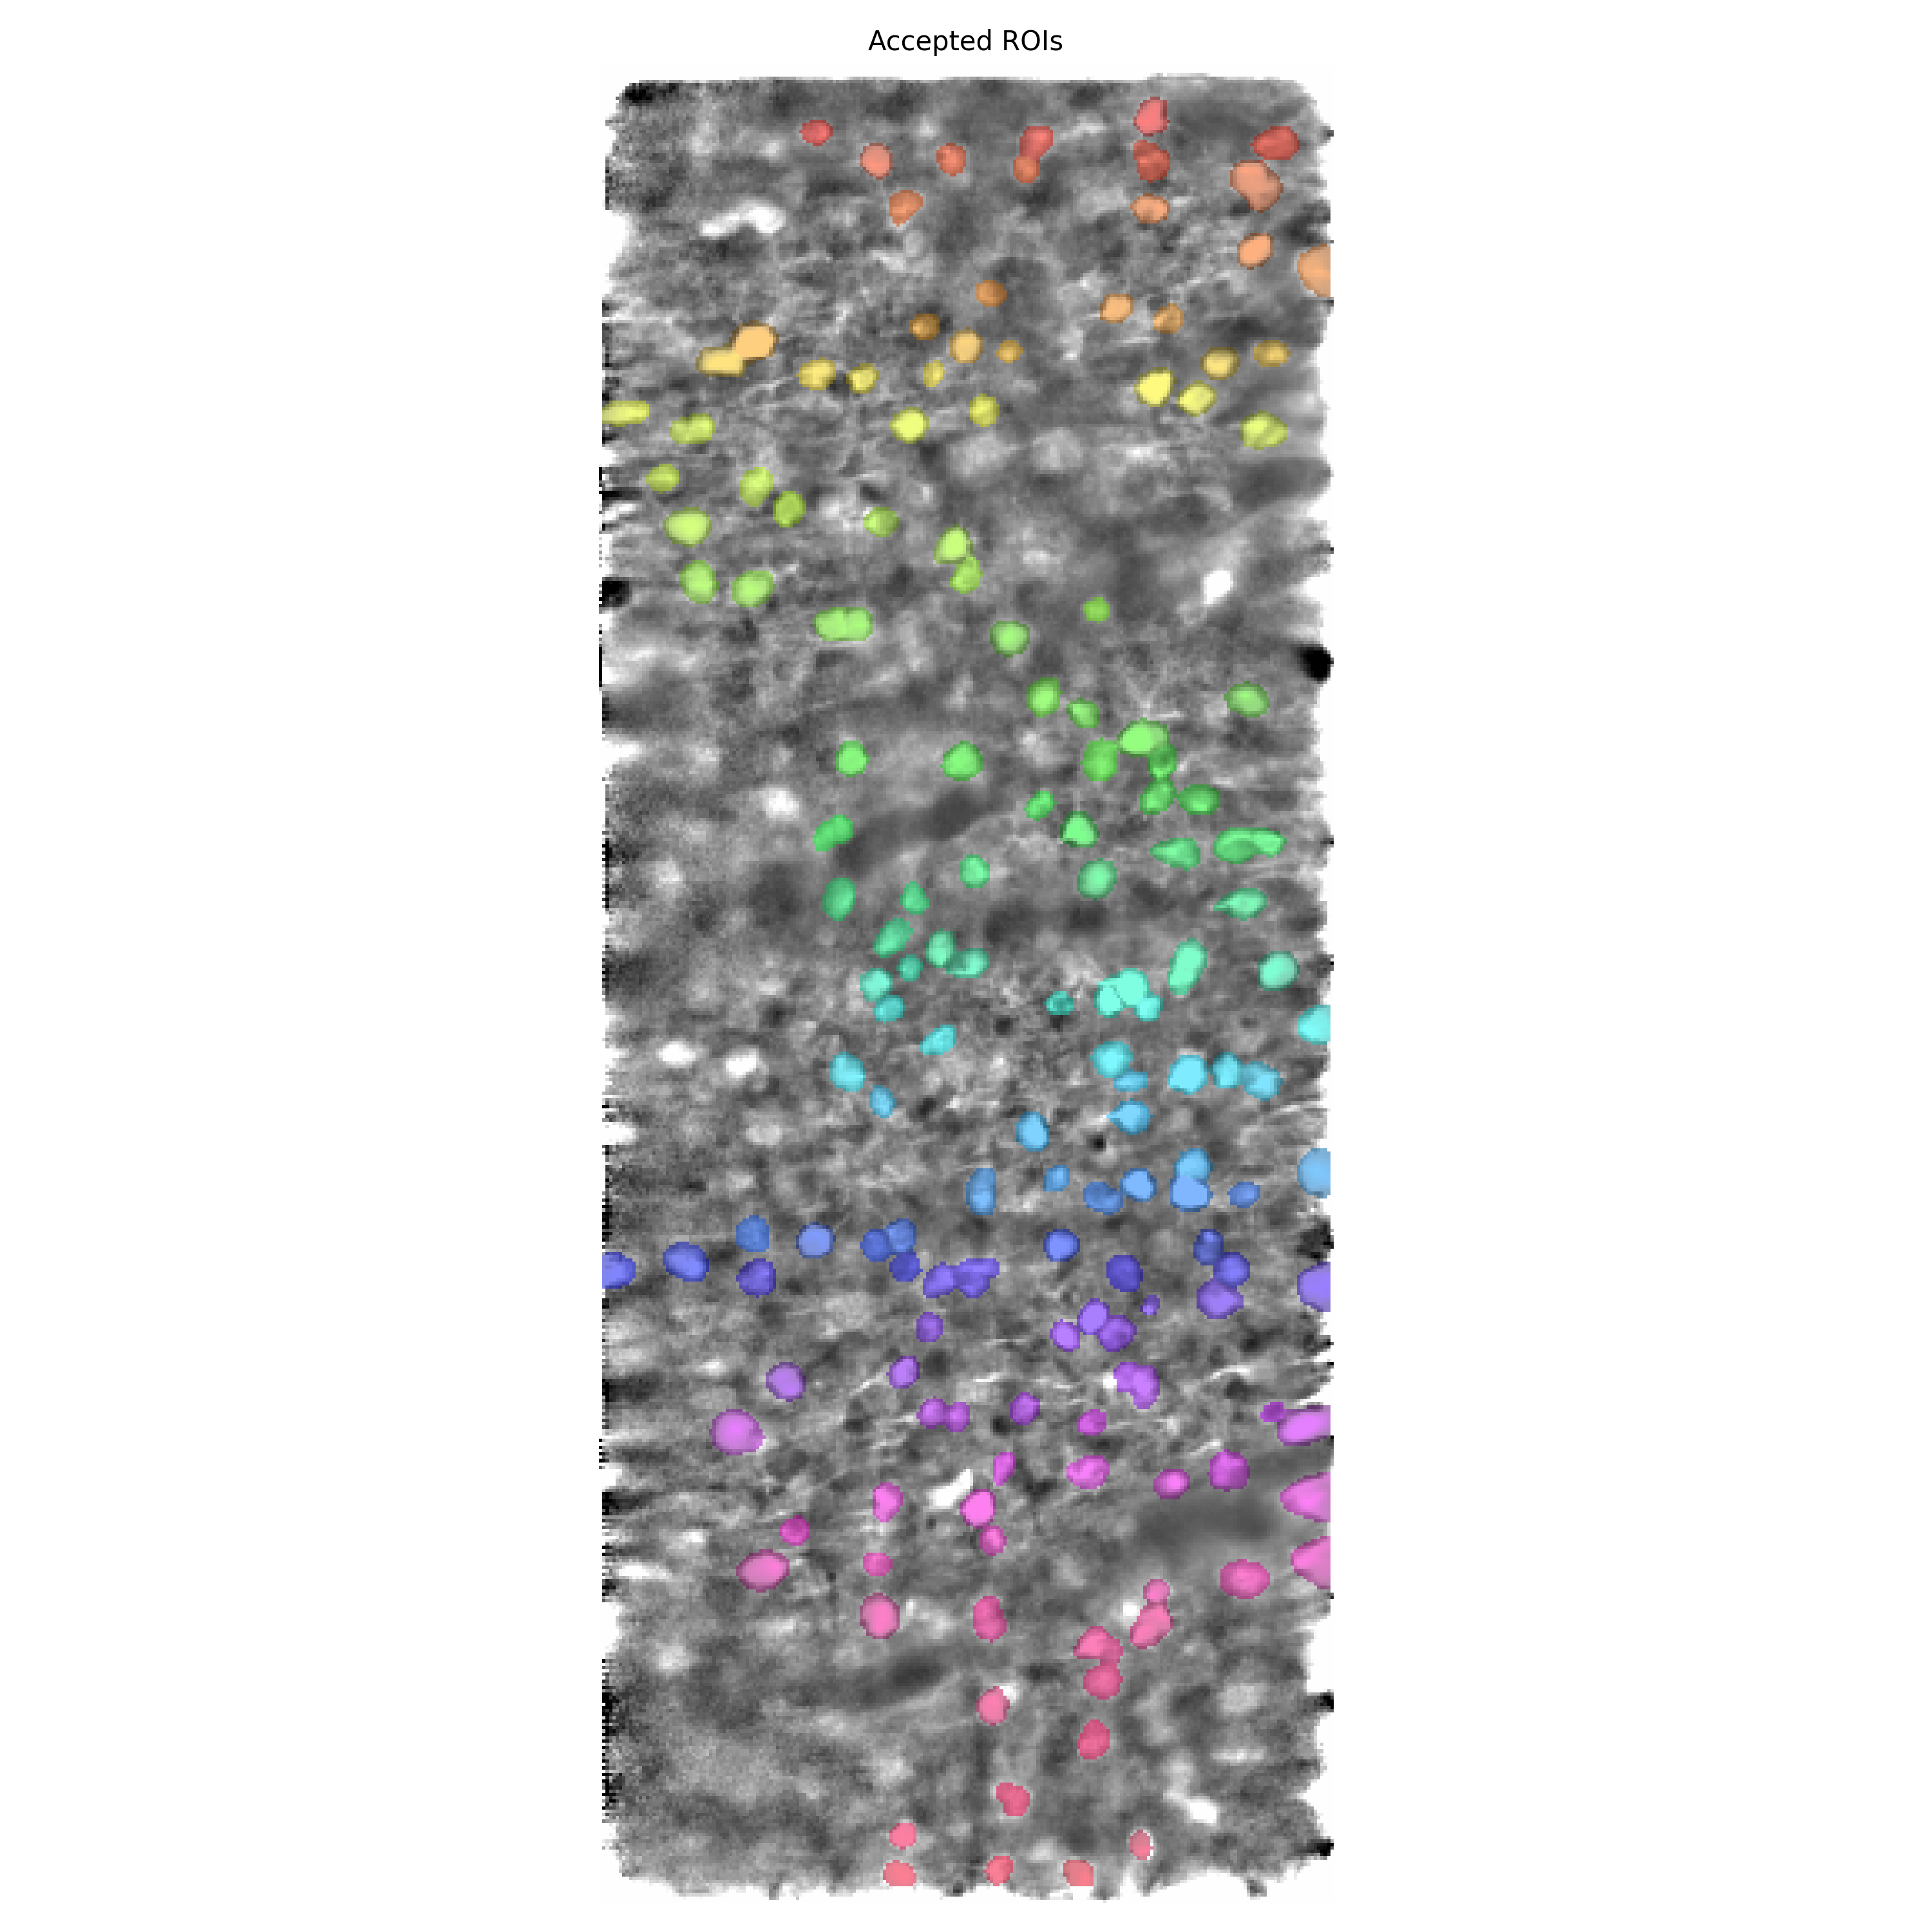
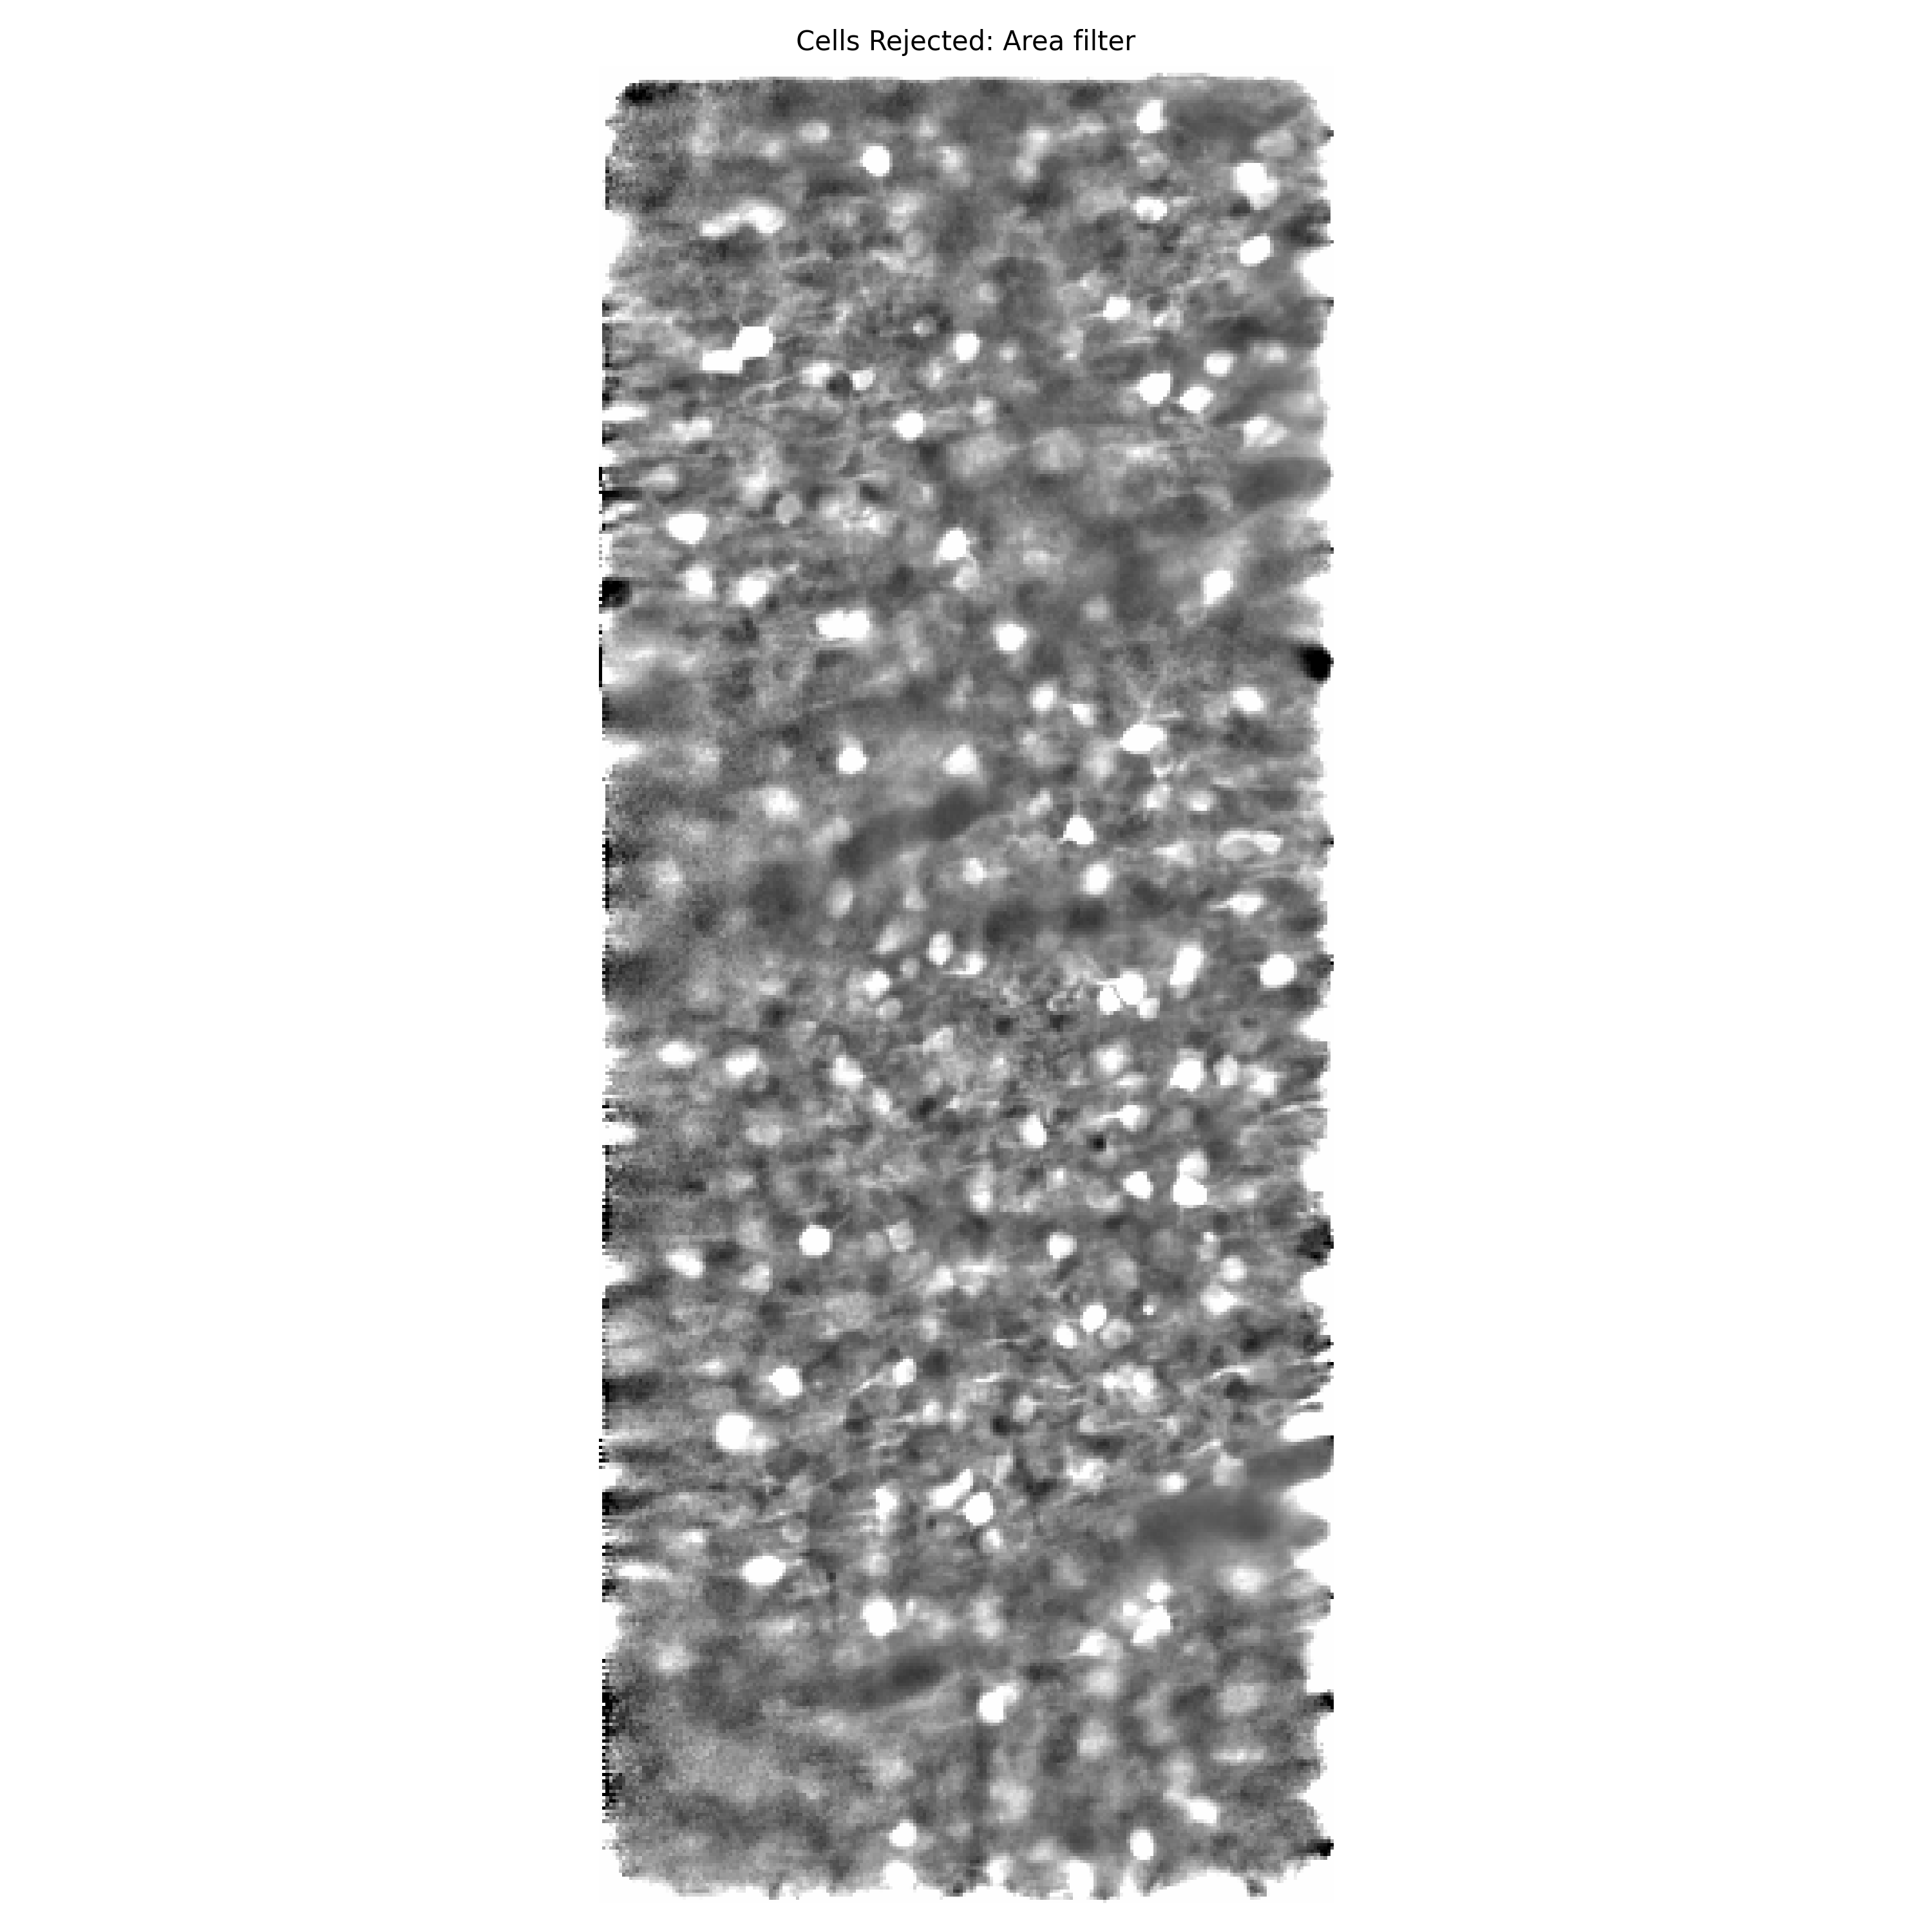
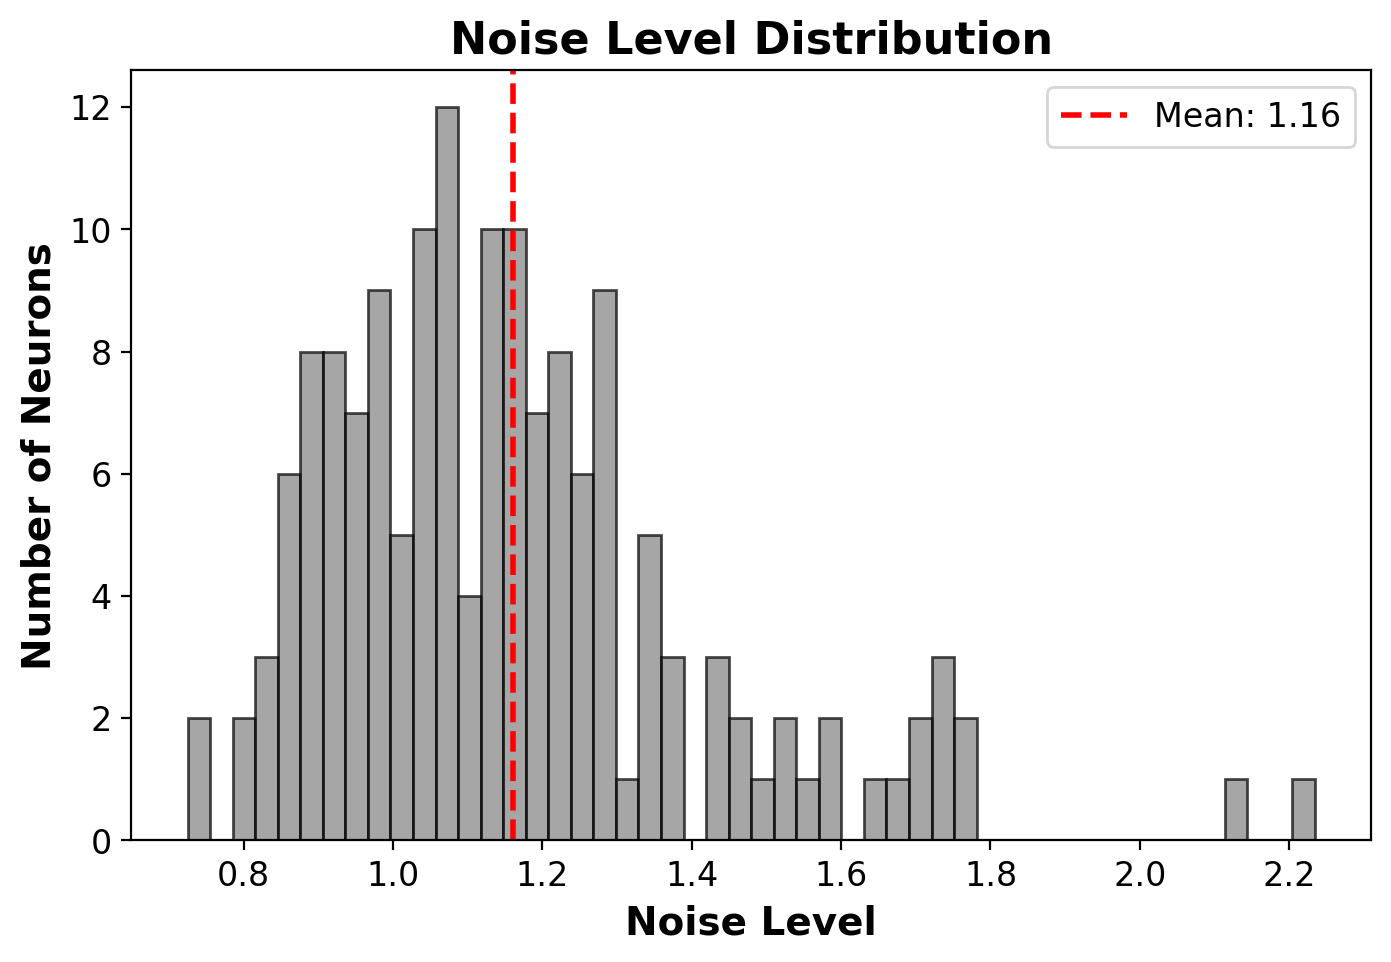
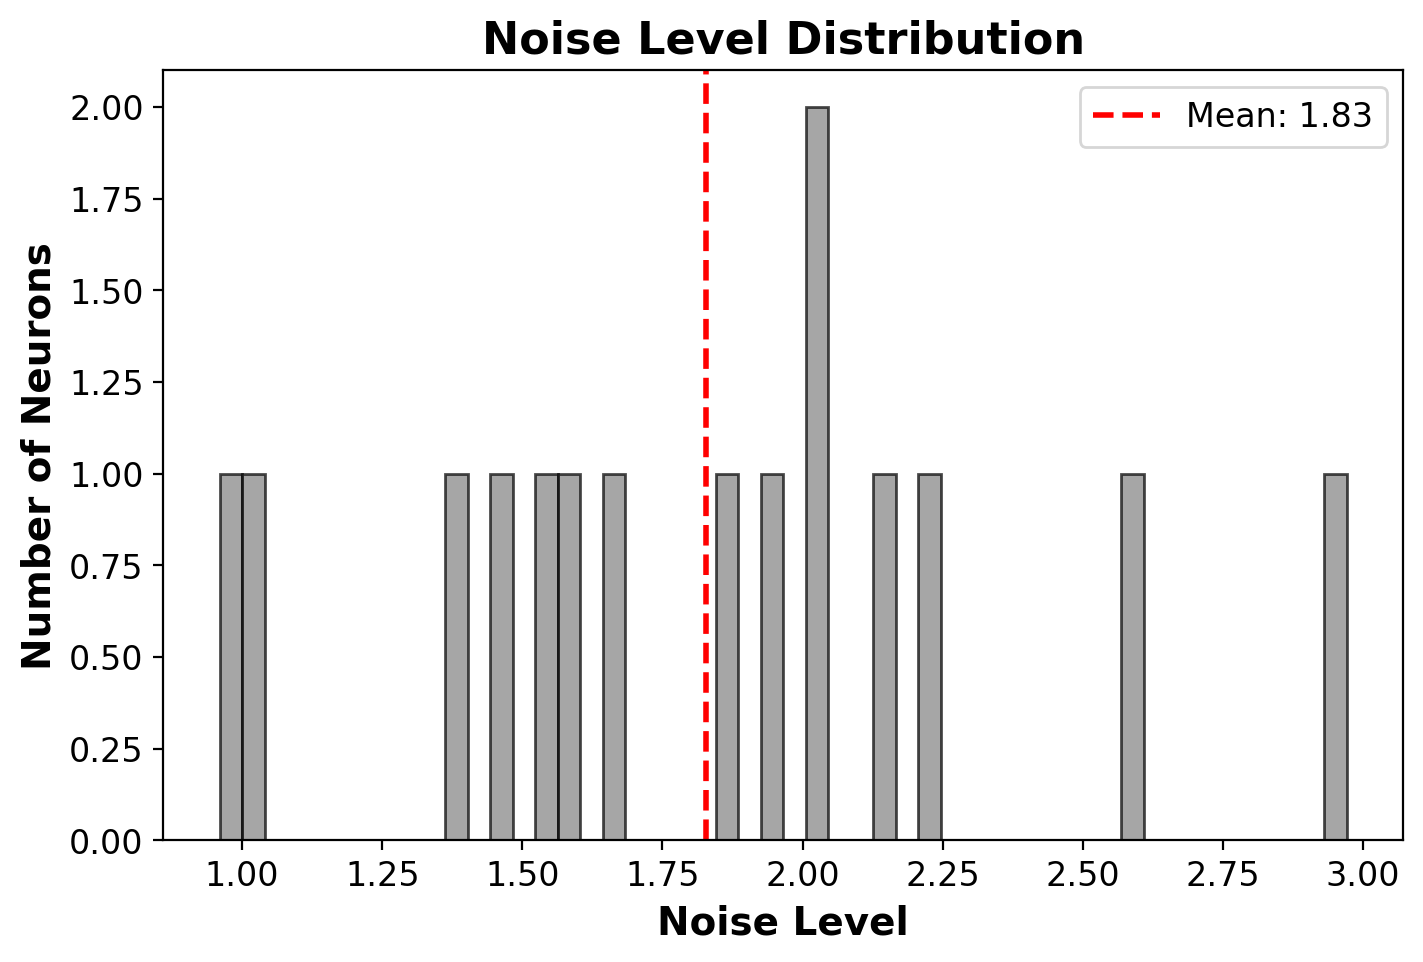
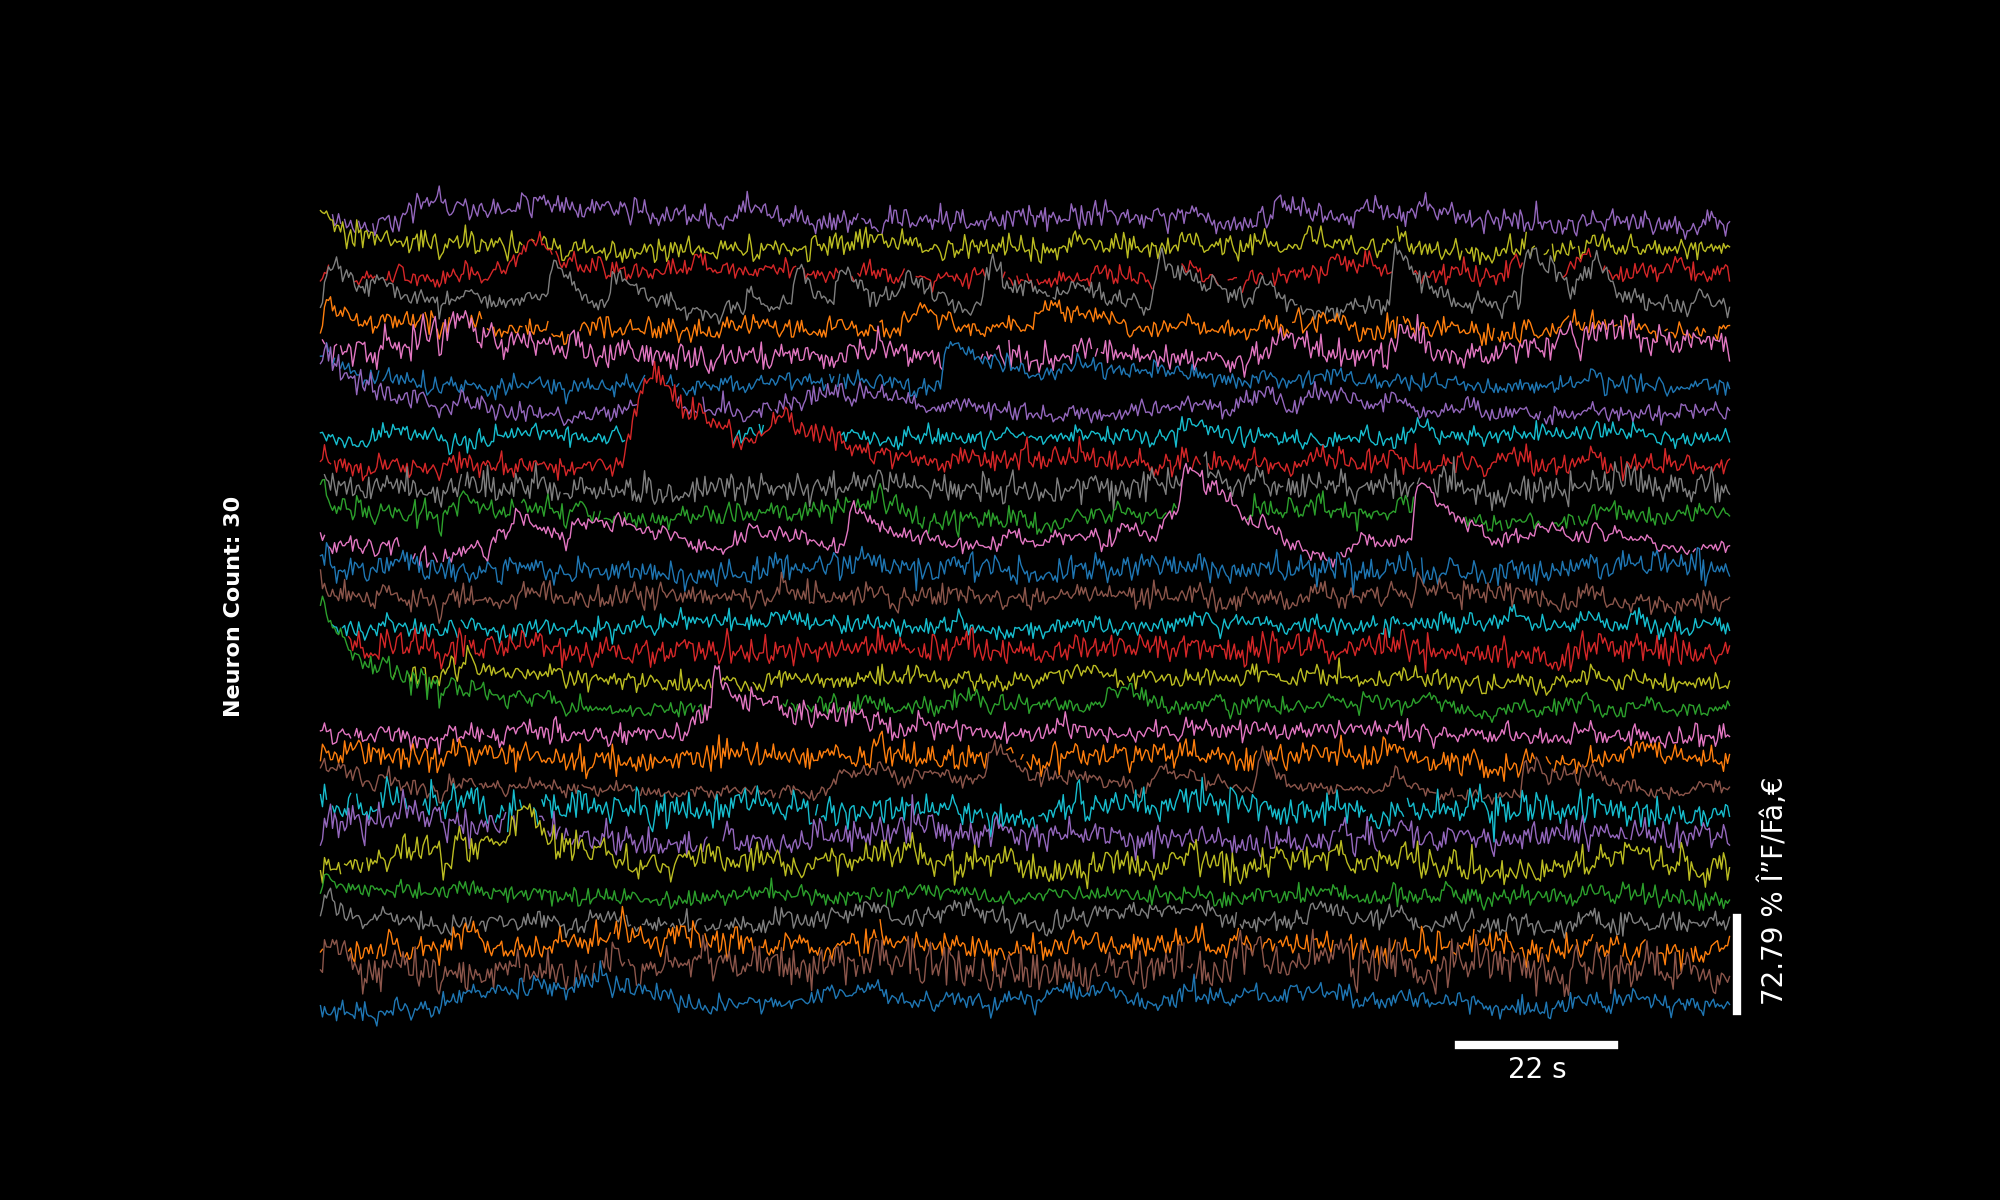
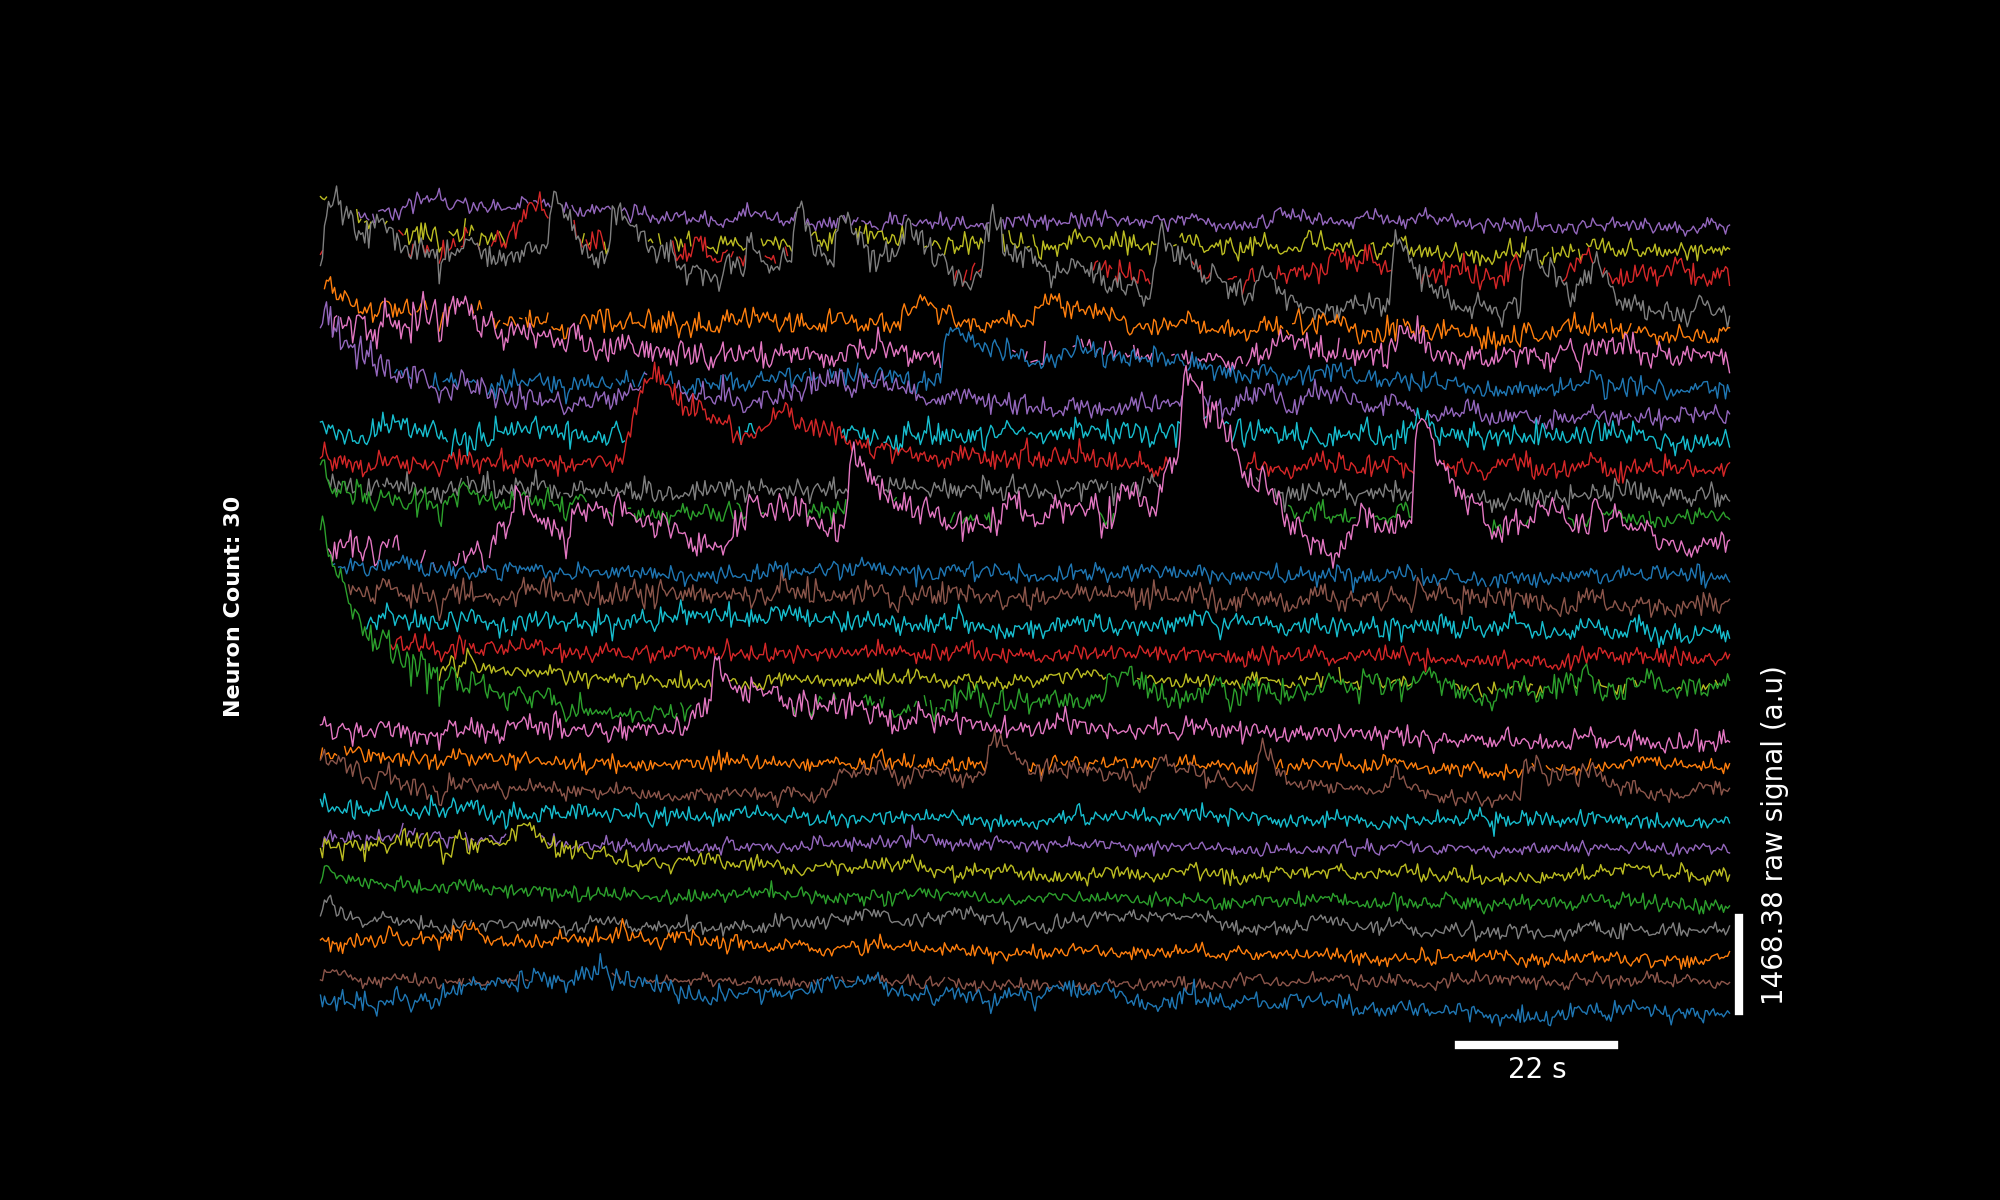

In [48]:
## This is just to show the default outputs in jupyter for convenience
from IPython.display import display, HTML
from pathlib import Path
import base64

def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

png_files = list(Path(save_path).rglob("*.png"))

html = "<div style='display: flex; gap: 12px;'>"
for p in png_files:
    img_b64 = image_to_base64(p)
    html += f"""
    <div style='text-align: center'>
        <img src='data:image/png;base64,{img_b64}' width='400px'>
        <div style='color: white; font-size: 12px'>{p.name}</div>
    </div>
    """
html += "</div>"

display(HTML(html))

In [49]:
statfile = mbo.get_files(save_path, 'stat', 2)[0]
statfile

WindowsPath('D:/demo/suite2p/stat.npy')

## Open Suite2p GUI 

- suite2p registration visualization: if you set `keep_reg` = True, you can view the raw movie with suite2p -> registration -> view registration binary
- if you set `keep_raw` = True, the checkbox "view raw binary" will show a side-by-side of your registered / raw movies
- if you have > 1500 frames, click suite2p -> registration -> view registration metrics, to view top/bottom PC's to look for activity (good) or motion (bad)

In [52]:
from suite2p import gui
gui.run(statfile=str(statfile))

D:\demo\suite2p\stat.npy
no channel 2 labels found (redcell.npy)
time to draw and plot masks:  0.0340 sec


SystemExit: 0

## Run volume
- acts the same as `run_plane` but accepts a list of files and creates some visualizations / statistics from the collated z-planes.
- if more than 1 mROI is detected (e.g. plane_1_roi1, plane_1_roi2), *results will be merged* after each plane/mROI is processed
- if for some reason the pipeline stops mid-process, you can re-run already processed input files with `overwrite=False` to skip re-processing and continue where you left off

In [7]:
new_ops = {
    "anatomical_only": 3,
    "two_step_registration": True,
}

save_path = r"D://demo//volumetric_suite2p"  # will be created if it doesn't exist
lsp.run_volume(
    input_files=input_files,
    save_path=save_path,
    ops=new_ops,
)

ops['roidetect'] is True with no stat.npy file present, proceeding with segmentation/detection for plane 1.


Saving data_raw.bin:   0%|          | 0/9 [00:00<?, ?it/s]

NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 14.99 sec.
Registered 500/701 in 57.10s
Registered 701/701 in 78.32s
----------- Total 95.22 sec
----------- ROI DETECTION
Binning movie in chunks of length 14
Binned movie of size [50,540,218] created in 0.22 sec.


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.12.9 
torch version:  	2.8.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




model_type argument is not used in v4.0.1+. Ignoring this argument...


>>>> CELLPOSE finding masks in enhanced_mean_img
!NOTE! diameter set to 8.00 for cell detection with cellpose
Cellpose using GPU: True


...

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is depricated in v4.0.1+


>>>> 56 masks detected, median diameter = 8.67 
Detected 56 ROIs, 2.81 sec
After removing overlaps, 56 ROIs remain
----------- Total 2.98 sec.
----------- EXTRACTION
Masks created, 0.08 sec.
Extracted fluorescence from 56 ROIs in 701 frames, 0.14 sec.
----------- Total 0.23 sec.
----------- CLASSIFICATION
['npix_norm', 'skew', 'compact']
----------- SPIKE DECONVOLUTION
----------- Total 0.00 sec.
1500 frames needed for registration metrics, found 701. Skipping PC metrics.
Time for D:\demo\mrois\plane14_roi1.tif: 0.3 min
CPU 45.3% | RAM 56.77 GB
Roi detection skipped, stat.npy already exists for plane 1.
Skipping data_raw.bin write, already exists and passes data validation checks.
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- REGISTRATION
Reference frame, 4.62 sec.
Registered 500/701 in 4.40s
Registered 701/701 in 6.32s
----------- Total 11.02 sec
1500 frames needed for registration metrics, found 701. Skipping PC metrics.
Time for D:\demo\mro

Merging mROIs: 0plane [00:00, ?plane/s]

Planes found after merge: 0
No ops files found.
Volume statistics failed.
Traceback:  Traceback (most recent call last):
  File "C:\Users\RBO\repos\LBM-Suite2p-Python\lbm_suite2p_python\run_lsp.py", line 219, in run_volume
    plot_volume_neuron_counts(zstats_file, save_path)
  File "C:\Users\RBO\repos\LBM-Suite2p-Python\lbm_suite2p_python\volume.py", line 218, in plot_volume_neuron_counts
    zstats = Path(zstats)
             ^^^^^^^^^^^^
  File "C:\Users\RBO\AppData\Roaming\uv\python\cpython-3.12.9-windows-x86_64-none\Lib\pathlib.py", line 1162, in __init__
    super().__init__(*args)
  File "C:\Users\RBO\AppData\Roaming\uv\python\cpython-3.12.9-windows-x86_64-none\Lib\pathlib.py", line 373, in __init__
    raise TypeError(
TypeError: argument should be a str or an os.PathLike object where __fspath__ returns a str, not 'NoneType'

Processing completed for 28 files.


[]